# Etna Dataset

This notebook builds the Etna case-study dataset for the Cause–Trigger analysis. The final hourly dataset combines the Wenchuan teleseismic waveform proxy, catalogue-derived local seismicity state/effect variables, soil CO₂, and meteorological proxy variables.

In [1]:
import sys
from pathlib import Path
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/etna"
sys.path.append(str(SRC_DIR))

from etna_config import (
    ETNA_WAVEFORM_CONFIG,
    ETNA_GAS_METEO_COLS,
    ETNA_EVENT_TIME,
    ETNA_WEATHER_COLS,
    etna_observable_metadata,
)

from etna_waveform import build_station_waveform_dataset

from etna_dataset import (
    load_etnagas_csv,
    load_etna_event_catalog_xls,
    create_etna_dataset,
    load_openmeteo_etna_weather,
)

from etna_plotting_utils import (
    dataset_health_report,
    plot_variable_pdfs,
    distribution_summary,
    run_teleseismic_checks,
    plot_etna_thesis_figures,
    plot_etna_all_variables_map,
    plot_etna_loglog_distributions,
)

client = Client("INGV")
cfg = ETNA_WAVEFORM_CONFIG
ETNA_STATION = ETNA_WAVEFORM_CONFIG["stations"][0]

import warnings
from obspy.io.mseed import InternalMSEEDWarning

warnings.filterwarnings(
    "ignore",
    category=InternalMSEEDWarning,
    message=r".*fractional second.*10000.*",
)
warnings.filterwarnings(
    "ignore",
    message=r".*fractional seconds.*10000.*",
)


## Etna station availability screening for full analysis window

This section identifies the best Etna seismic station(s) for the full analysis window without downloading the full waveform archive. It first discovers all available vertical channels, then probes a short waveform segment on each day of the study period. Stations are ranked by daily availability and distance to the Etna summit.

Keep `RUN_STATION_SCREENING = False` for normal dataset construction. Set it to `True` only if you want to rerun the reproducible station-selection check and export fresh CSV/TXT reports.


In [2]:
RUN_STATION_SCREENING = False  # Set to True to run station screening, False to skip and use selected station from config

if RUN_STATION_SCREENING:
    from etna.etna_stations import (
        run_station_screening,
        export_station_screening_results,
    )
    streams_found, daily_probe, station_summary = run_station_screening(
        client=client,
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        max_distance_km=80.0,
        probe_offset_hours=12,
        probe_duration_minutes=10,
        verbose=True,
        display_func=display,
    )

    export_paths = export_station_screening_results(
        station_summary=station_summary,
        daily_probe=daily_probe,
        out_dir="etna_stations",
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        probe_offset_hours=12,
        probe_duration_minutes=10,
    )

    print("\nRanked station-channel candidates:")
    display(station_summary)

    print("\nBest complete candidates:")
    display(station_summary.query("ok_fraction == 1.0"))

    print("\nSaved station-screening files:")
    for name, path in export_paths.items():
        print(f"{name}: {path}")
else:
    print(
        "Station screening skipped. "
        "Using selected station from ETNA_WAVEFORM_CONFIG: "
        f"{ETNA_STATION}.{ETNA_WAVEFORM_CONFIG['location']}.{ETNA_WAVEFORM_CONFIG['channel']}"
    )

Station screening skipped. Using selected station from ETNA_WAVEFORM_CONFIG: ESLN..HHZ


## Hourly waveform feature extraction

Waveform data are processed in daily chunks with padding for filter stability.


In [3]:
esln_wave, esln_failures = build_station_waveform_dataset(
    client=client,
    station=ETNA_STATION,
    cfg=cfg,
    cache_path="../data/etna/etna_esln_hhz_waveform.pkl",
    redownload=True, #set True to force redownloading, False to use cached dataset
)

print("failures:", esln_failures)
print("shape:", esln_wave.shape)
display(esln_wave.head())
display(esln_wave.tail())
display(esln_wave.isna().mean())

ESLN OK  2008-04-12
ESLN OK  2008-04-13
ESLN OK  2008-04-14
ESLN OK  2008-04-15
ESLN OK  2008-04-16
ESLN OK  2008-04-17
ESLN OK  2008-04-18
ESLN OK  2008-04-19
ESLN OK  2008-04-20
ESLN OK  2008-04-21
ESLN OK  2008-04-22
ESLN OK  2008-04-23
ESLN OK  2008-04-24
ESLN OK  2008-04-25
ESLN OK  2008-04-26
ESLN OK  2008-04-27
ESLN OK  2008-04-28
ESLN OK  2008-04-29
ESLN OK  2008-04-30
ESLN OK  2008-05-01
ESLN OK  2008-05-02
ESLN OK  2008-05-03
ESLN OK  2008-05-04
ESLN OK  2008-05-05
ESLN OK  2008-05-06
ESLN OK  2008-05-07
ESLN OK  2008-05-08
ESLN OK  2008-05-09
ESLN OK  2008-05-10
ESLN OK  2008-05-11
ESLN OK  2008-05-12
ESLN OK  2008-05-13
ESLN OK  2008-05-14
ESLN OK  2008-05-15
ESLN: saved waveform features to ..\data\etna\etna_esln_hhz_waveform.pkl
failures: []
shape: (816, 1)


,teleseismic
time,
2008-04-12 00:00:00+00:00,1.256462e-05
2008-04-12 01:00:00+00:00,4.973278e-06
2008-04-12 02:00:00+00:00,9.794816e-06
2008-04-12 03:00:00+00:00,8.487838e-07
2008-04-12 04:00:00+00:00,1.288926e-05


,teleseismic
time,
2008-05-15 19:00:00+00:00,9.823866e-08
2008-05-15 20:00:00+00:00,1.034400e-07
2008-05-15 21:00:00+00:00,1.118294e-07
2008-05-15 22:00:00+00:00,1.150171e-07
2008-05-15 23:00:00+00:00,8.500849e-05


teleseismic    0.0
dtype: float64

## External variables

These variables are merged onto the hourly waveform grid:

- WindSpeed [1] 
- CO2_3 [1] 
- pressure_drop (derived from Patm_3 column) [1]
- rainfall_mm: hourly Open-Meteo precipitation proxy [2]

[1] Liuzzo, M., Giuffrida, G. B., & Gurrieri, S. (2025). Etna CO2 Soil Flux during 2002-2010 (ECSF2002_2010) [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV). https://doi.org/10.13127/etna/ecsf2002_2010

[2] Zippenfenig, P. (2023). Open-Meteo.com Weather API [Computer software]. Zenodo. https://doi.org/10.5281/ZENODO.7970649


In [4]:
etnagas_df = load_etnagas_csv(
    path="../data/etna/3c.csv",
    value_cols=ETNA_GAS_METEO_COLS,
)

display(etnagas_df.head())
display(etnagas_df.isna().mean().sort_values())

,timestamp,CO2_3,pressure_drop,WindSpeed
0,2008-01-18 00:00:00+00:00,0.283836,NaN,0.0
1,2008-01-18 01:00:00+00:00,0.287348,NaN,0.0
2,2008-01-18 02:00:00+00:00,0.274303,NaN,0.0
3,2008-01-18 03:00:00+00:00,0.269285,NaN,0.0
4,2008-01-18 04:00:00+00:00,0.265773,NaN,0.0


timestamp        0.000000
WindSpeed        0.012125
CO2_3            0.014249
pressure_drop    0.024521
dtype: float64

In [5]:
etna_weather_df = load_openmeteo_etna_weather(
    start_date="2008-04-12",
    end_date="2008-05-16",
)

## Mt. Etna Seismic Catalog 2000-2010

From this catalogue, two hourly variables are constructed:
- local_event_rate_state: past-only 48 h local event-rate state
- local_event_rate_response: positive six-hour local event-count response
  relative to its past baseline, used as the effect variable

Alparone, S. C., Maiolino, V., Mostaccio, A., Scaltrito, A., Ursino, A., Barberi, G., et al. (2015). Mt. Etna Seismic Catalog 2000-2010 [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV) - Osservatorio Etneo. https://doi.org/10.13127/etnasc/2000_2010

In [6]:
etna_catalog = load_etna_event_catalog_xls(
    "../data/etna/Etna catalogue_2000-2010.xls",
    quality_filter=False,
)

print("Catalogue rows:", len(etna_catalog))
print("Catalogue time range:", etna_catalog["timestamp"].min(), "to", etna_catalog["timestamp"].max())

display(etna_catalog.head())
display(etna_catalog.tail())

Catalogue rows: 6328
Catalogue time range: 2000-01-01 01:21:26+00:00 to 2010-12-31 05:53:46+00:00


,ID,YE,MO,DA,HR,MI,SE,MD,ML,LAT,LON,DEPSL,DEPGL,N.O.,RMS,GAP,ERZ,ERH,timestamp
0,1,2000,1,1,1,21,26,1.3,NaN,37.794,14.989,6.85,9.19,8,0.05,318,3.2,2.0,2000-01-01 01:21:26+00:00
1,2,2000,1,1,7,39,41,2.1,NaN,37.643,15.067,1.48,2.26,9,0.13,170,1.0,0.5,2000-01-01 07:39:41+00:00
2,3,2000,1,1,7,44,19,2.6,NaN,37.643,15.062,0.57,1.38,11,0.12,170,1.1,0.3,2000-01-01 07:44:19+00:00
3,4,2000,1,2,4,15,12,2.7,NaN,37.645,15.062,1.37,2.21,9,0.13,166,0.9,0.3,2000-01-02 04:15:12+00:00
4,5,2000,1,2,21,22,46,1.1,NaN,37.713,14.995,4.04,6.40,8,0.05,248,1.1,1.2,2000-01-02 21:22:46+00:00


,ID,YE,MO,DA,HR,MI,SE,MD,ML,LAT,LON,DEPSL,DEPGL,N.O.,RMS,GAP,ERZ,ERH,timestamp
6323,6324,2010,12,25,21,53,52,1.2,1.2,37.713,15.059,3.11,4.80,11,0.07,153,0.4,0.7,2010-12-25 21:53:52+00:00
6324,6325,2010,12,27,0,36,46,1.1,0.9,37.745,15.112,3.89,4.81,15,0.16,80,0.7,0.3,2010-12-27 00:36:46+00:00
6325,6326,2010,12,27,13,34,18,1.4,1.1,37.723,15.052,2.48,4.07,9,0.06,182,1.2,1.6,2010-12-27 13:34:18+00:00
6326,6327,2010,12,30,22,20,16,1.4,1.1,37.683,15.037,4.03,5.52,9,0.08,186,0.5,0.5,2010-12-30 22:20:16+00:00
6327,6328,2010,12,31,5,53,46,1.2,1.0,37.705,15.070,3.04,4.38,7,0.07,143,0.8,1.5,2010-12-31 05:53:46+00:00


## Merge, scale, and save final hourly datasets

The waveform, gas, meteorological variables are merged by timestamp. Raw variables are retained, and scaled versions are produced for causal discovery. 

In [8]:
etna_dataset = create_etna_dataset(
    wave_df=esln_wave,
    station_name=ETNA_STATION,
    start_time=ETNA_WAVEFORM_CONFIG["start"].isoformat(),
    end_time=ETNA_WAVEFORM_CONFIG["end"].isoformat(),
    catalog_df=etna_catalog,
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_GAS_METEO_COLS,
    weather_df=etna_weather_df,
    weather_cols=ETNA_WEATHER_COLS,
    output_dir="../data/etna",
)

## Dataset checks

We check dataset size, timestamp order, duplicate timestamps, missing values, and variable distributions. These checks ensure that the final hourly dataset is suitable for causal discovery.

In [9]:
dataset_health_report(etna_dataset, "Etna analysis dataset")


Etna analysis dataset
shape: (787, 9)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station                      0.0
time                         0.0
teleseismic                  0.0
local_event_rate_state       0.0
local_event_rate_response    0.0
CO2_3                        0.0
pressure_drop                0.0
WindSpeed                    0.0
rainfall_mm                  0.0
dtype: float64


### Distribution diagnostics

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


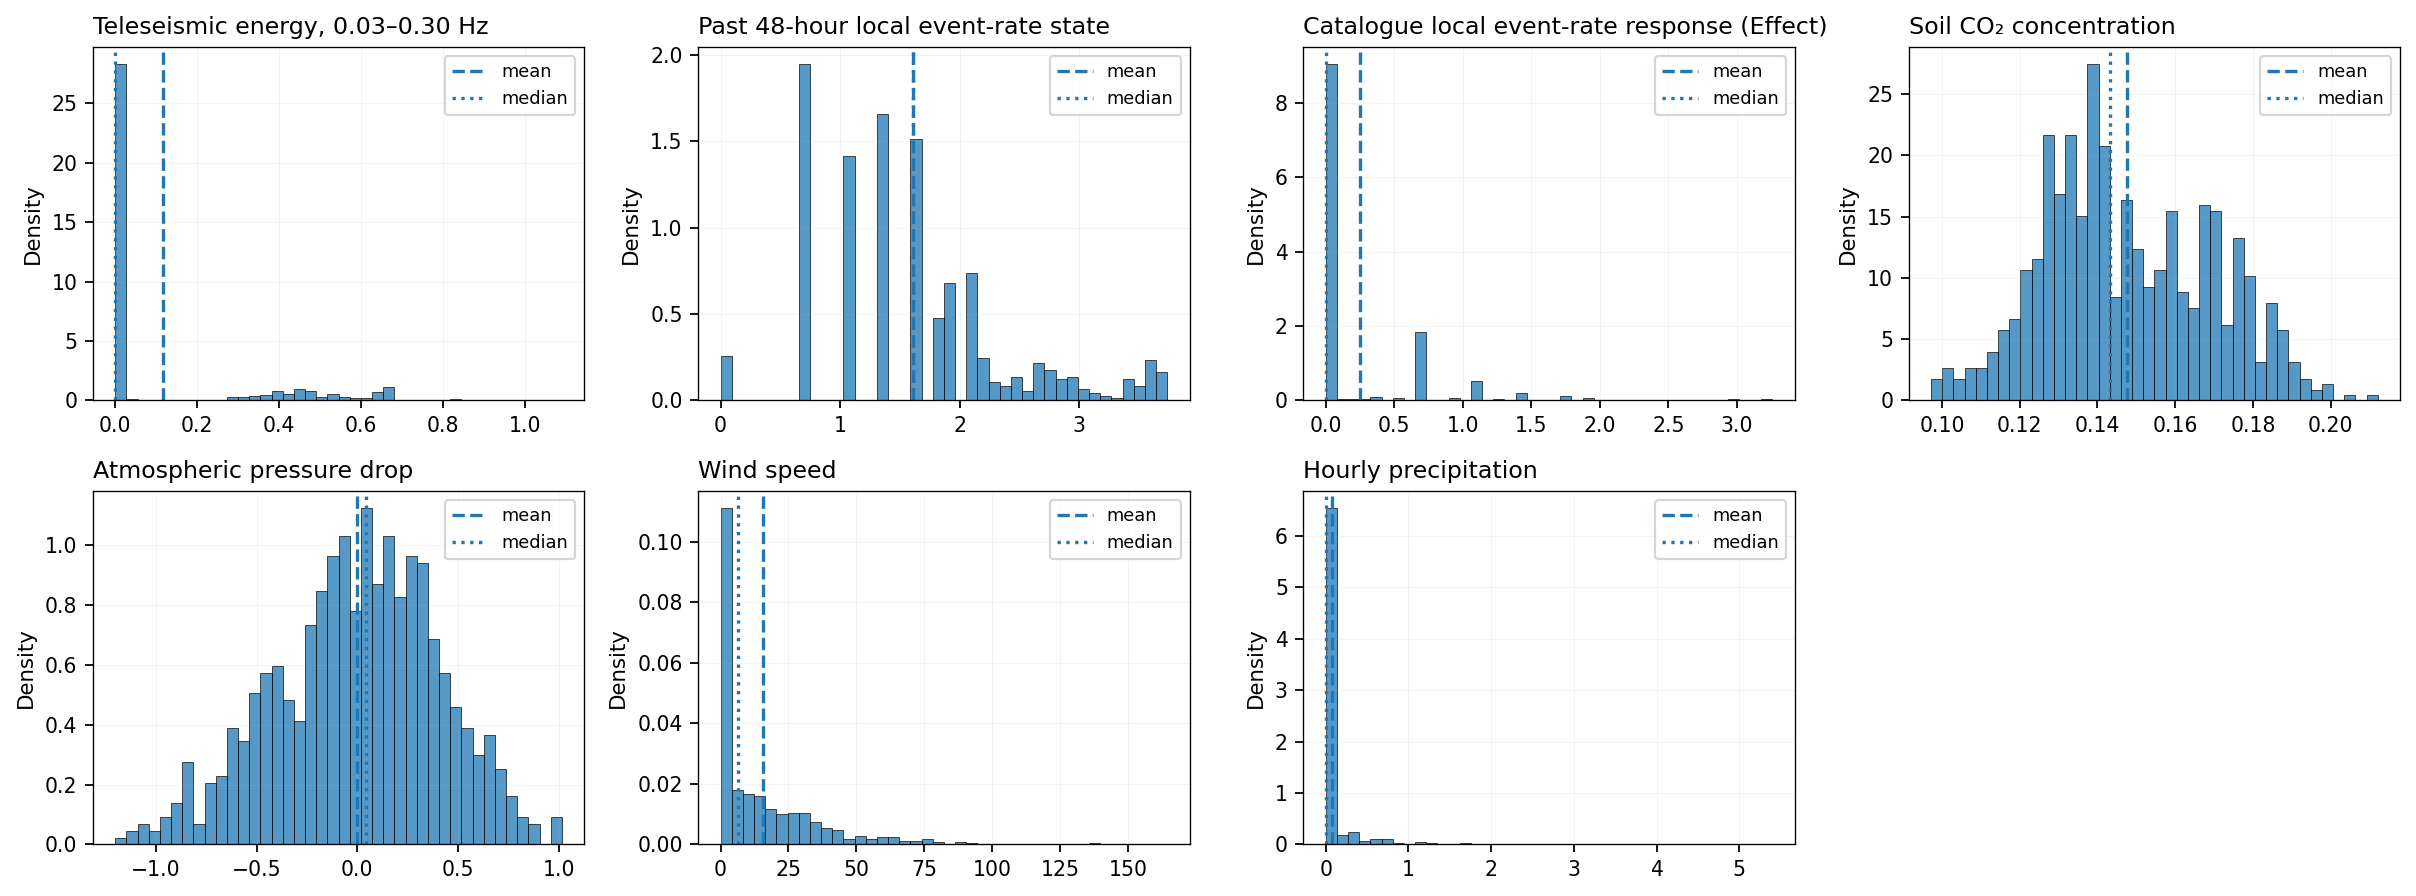

In [10]:
plot_variable_pdfs(etna_dataset, filename="etna_pdf")

### distribution summary table

In [11]:
summary_esln = distribution_summary(etna_dataset)
display(summary_esln)

,count,mean,std,min,median,max,skew,n_unique,missing_fraction
CO2_3,787.0,0.147545,0.021588,9.718300e-02,1.433440e-01,0.212085,0.223187,164,0.0
WindSpeed,787.0,15.716718,22.233596,0.000000e+00,6.557377e+00,164.344262,2.297918,164,0.0
local_event_rate_response,787.0,0.246501,0.493311,0.000000e+00,0.000000e+00,3.258097,2.648462,31,0.0
local_event_rate_state,787.0,1.609146,0.805061,0.000000e+00,1.609438e+00,3.737670,0.683825,36,0.0
pressure_drop,787.0,-0.002436,0.407693,-1.201602e+00,4.291400e-02,1.015640,-0.248652,296,0.0
rainfall_mm,787.0,0.074079,0.291550,0.000000e+00,0.000000e+00,5.400000,9.738744,16,0.0
teleseismic,787.0,0.115409,0.223117,7.554136e-08,3.243009e-07,1.091039,1.642697,787,0.0


### Etna variable log-log distributions

a visual diagnostic for scale, tails, and zero inflation.

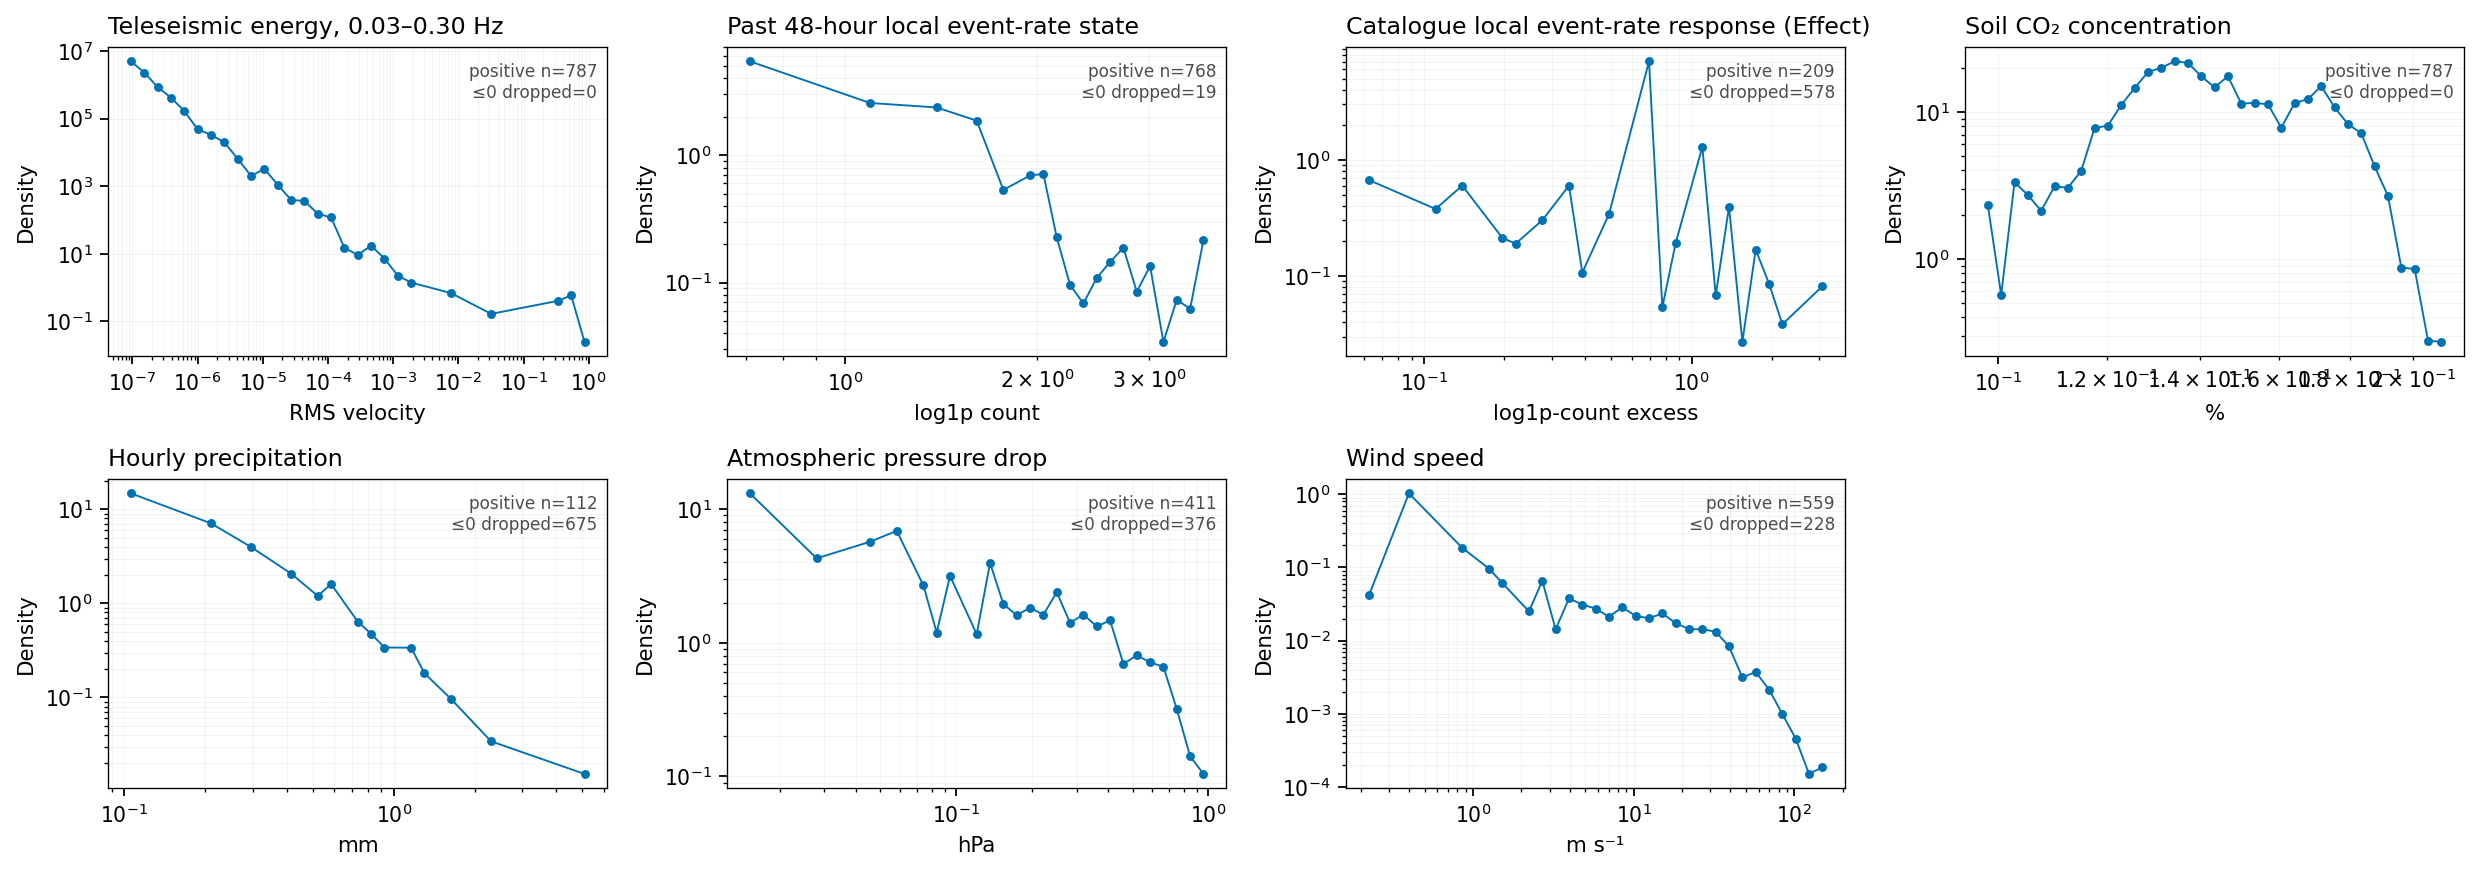

,variable,n_total_nonmissing,n_positive_used,n_nonpositive_dropped,positive_fraction,min_positive,max_positive,n_unique_positive
0,teleseismic,787,787,0,1.000000,7.554136e-08,1.091039,787
1,local_event_rate_state,787,768,19,0.975858,6.931472e-01,3.737670,35
2,local_event_rate_response,787,209,578,0.265565,5.889152e-02,3.258097,30
3,CO2_3,787,787,0,1.000000,9.718300e-02,0.212085,164
4,rainfall_mm,787,112,675,0.142313,1.000000e-01,5.400000,15
5,pressure_drop,787,411,376,0.522236,1.430400e-02,1.015640,147
6,WindSpeed,787,559,228,0.710292,2.049180e-01,164.344262,163


In [12]:
fig, axes, etna_loglog_report = plot_etna_loglog_distributions(
    etna_dataset,
    save_dir="figures",
)

display(etna_loglog_report)

## Teleseismic arrival diagnostics

We inspect the Etna waveform around the Wenchuan earthquake origin-time
reference. The local arrival and amplitude of the teleseismic disturbance arerepresented by the measured Etna waveform proxy rather than assumed from the origin timestamp. The 1-minute RMS is compared with hourly maximum aggregation to verify that the hourly grid preserves the teleseismic-arrival energy. The spectrogram documents the 0.03–0.30 Hz teleseismic proxy band used for the final Etna trigger variable.

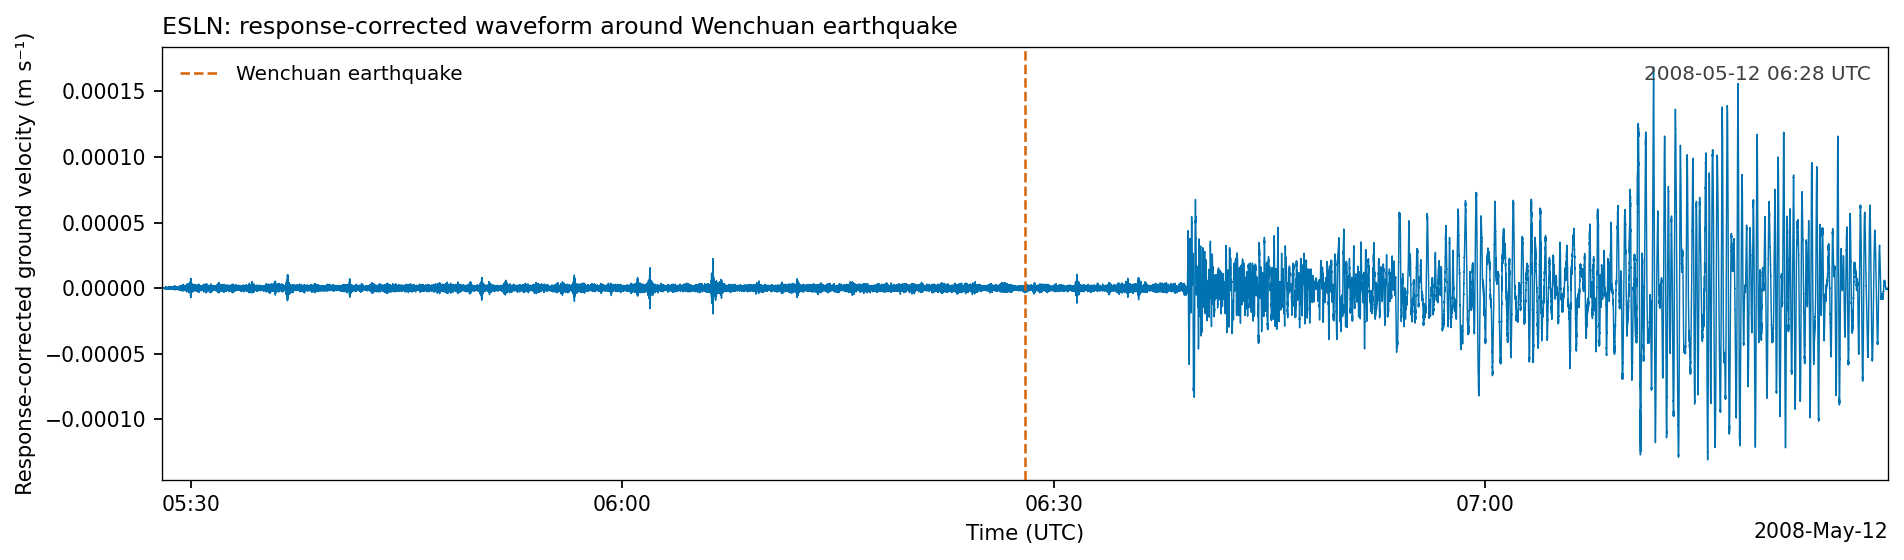

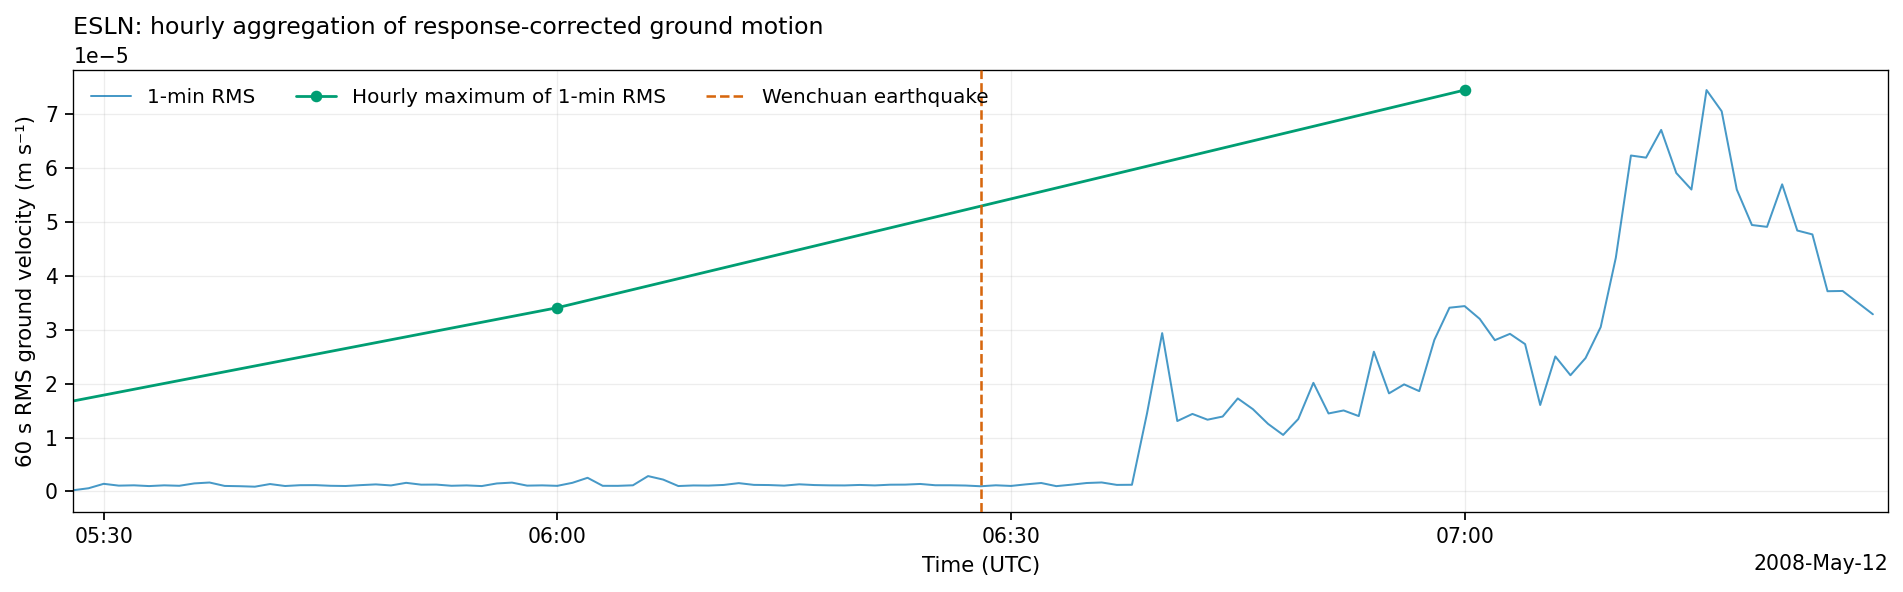


ESLN
1-min peak: 2008-05-12 07:16:00+00:00
hourly peak bin: 2008-05-12 07:00:00+00:00
difference: 0 days 00:16:00


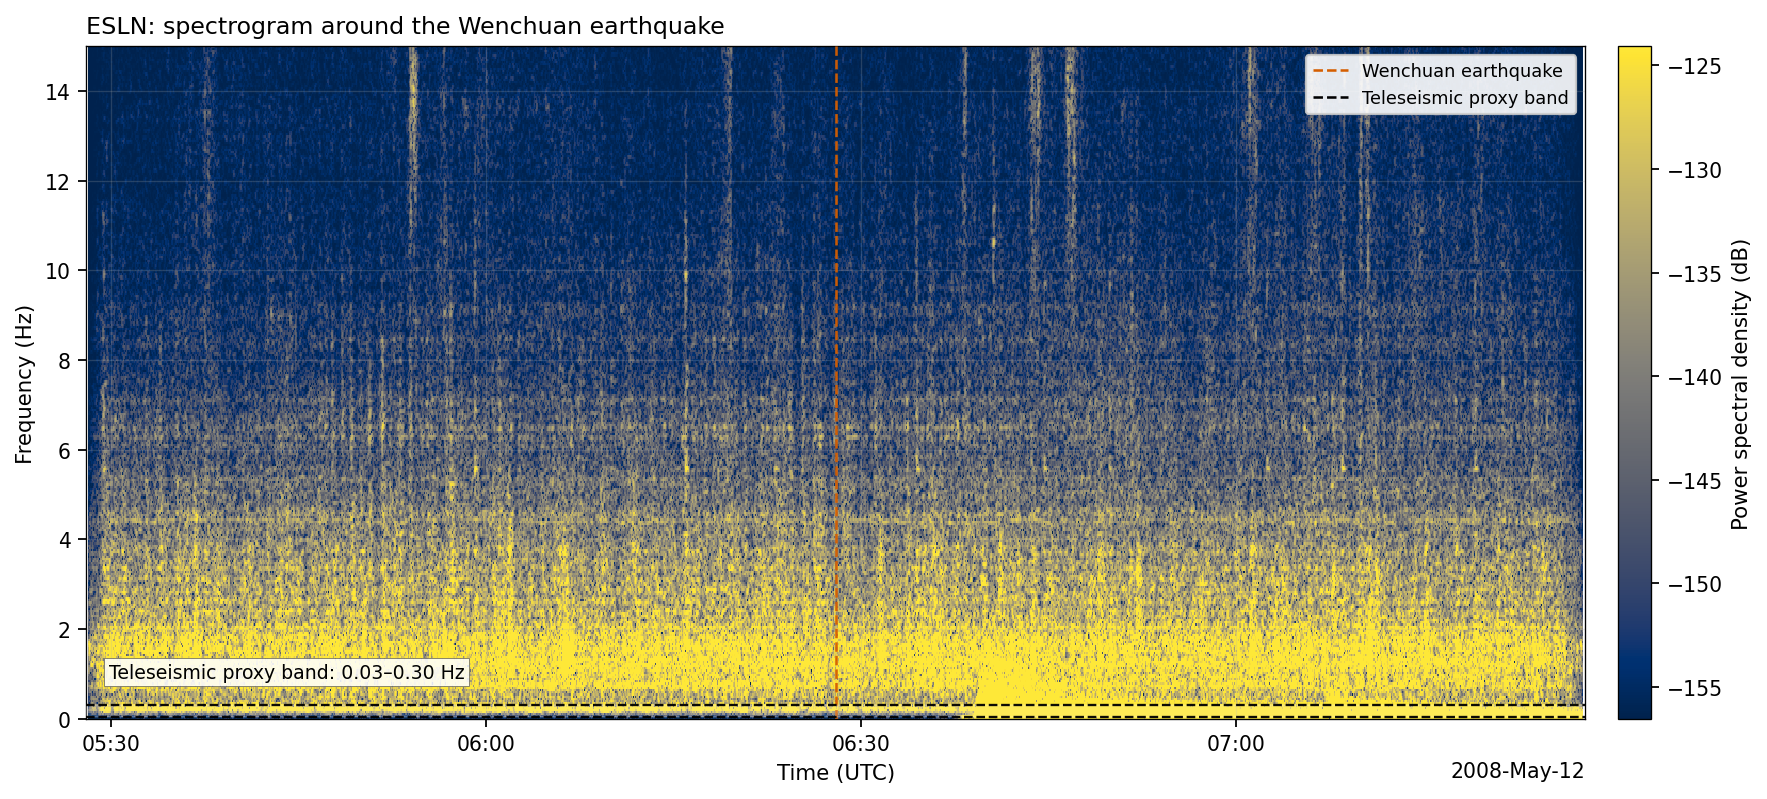

In [14]:
waveform_client = Client(
    base_url="https://webservices.ingv.it",
    service_mappings={
        "dataselect": "https://webservices.ingv.it/fdsnws/dataselect/1/",
        "station": "https://webservices.ingv.it/fdsnws/station/1/",
        "event": "https://webservices.ingv.it/fdsnws/event/1/",
    },
    _discover_services=False,
)

results = {}

results[ETNA_STATION] = run_teleseismic_checks(
    client=waveform_client,
    station=ETNA_STATION,
    cfg=ETNA_WAVEFORM_CONFIG,
    event_time=ETNA_EVENT_TIME,
)

## Final hourly dataset with event marker

The final dataset is plotted with the teleseismic event time marked. This provides a visual check that the causal-analysis dataset aligns with the known event window.

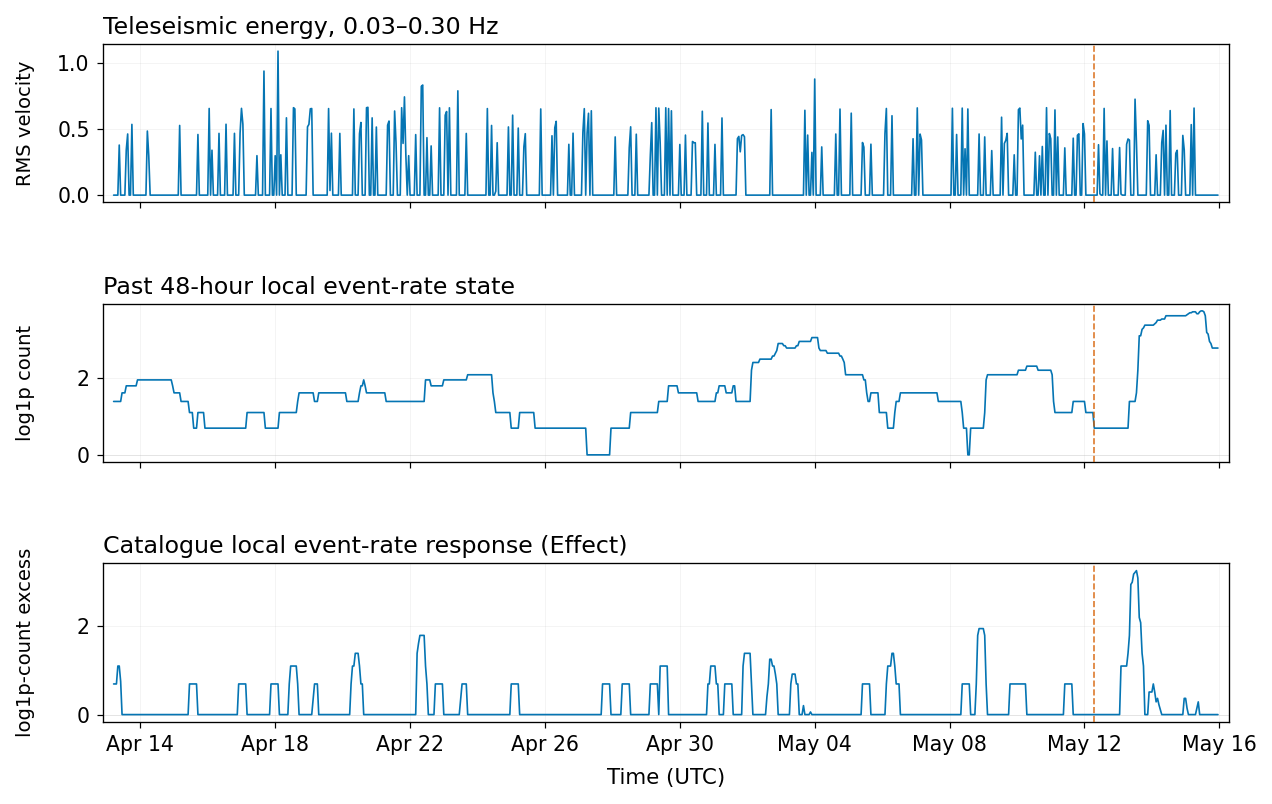

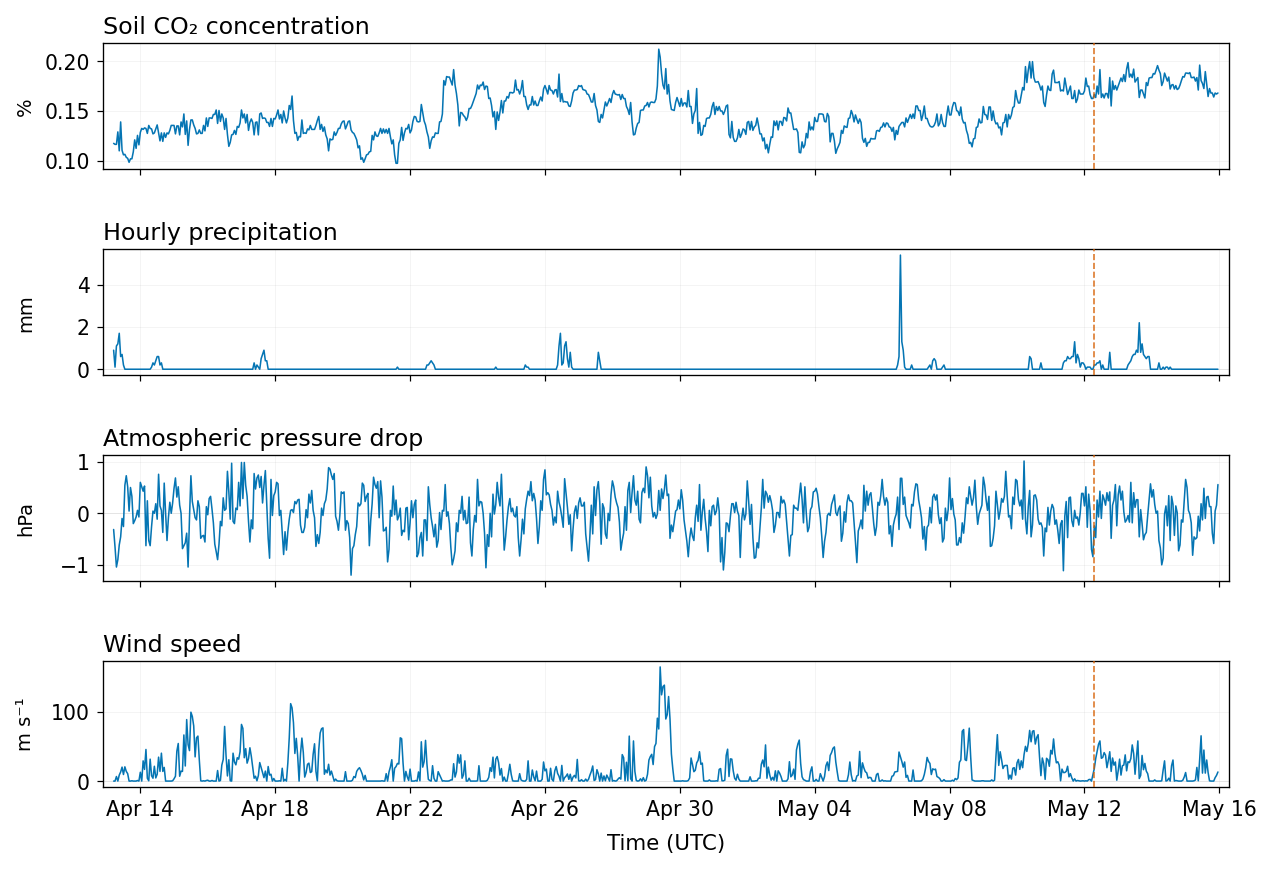

((<Figure size 1280x761.6 with 3 Axes>,
  array([<Axes: title={'left': 'Teleseismic energy, 0.03–0.30 Hz'}, ylabel='RMS velocity'>,
         <Axes: title={'left': 'Past 48-hour local event-rate state'}, ylabel='log1p count'>,
         <Axes: title={'left': 'Catalogue local event-rate response (Effect)'}, xlabel='Time (UTC)', ylabel='log1p-count excess'>],
        dtype=object)),
 (<Figure size 1280x835.2 with 4 Axes>,
  array([<Axes: title={'left': 'Soil CO₂ concentration'}, ylabel='%'>,
         <Axes: title={'left': 'Hourly precipitation'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='hPa'>,
         <Axes: title={'left': 'Wind speed'}, xlabel='Time (UTC)', ylabel='m s⁻¹'>],
        dtype=object)))

In [15]:
plot_etna_thesis_figures(
    csv_path="../data/etna/etna_dataset.csv",
    event_time=ETNA_EVENT_TIME,
    save_dir="figures",
    include_titles=False,
)

## Geographic Visualization

,Source,Source ID,Variables
0,ESLN,ESLN,teleseismic
1,ETNAGAS network,ETNAGAS_3,"CO2_3, pressure_drop, WindSpeed"
2,EtnaSC catalogue,EtnaSC_2000_2010,"local_event_rate_state, local_event_rate_response"
3,Open-Meteo,ETNA_OPENMETEO_PROXY,rainfall_mm


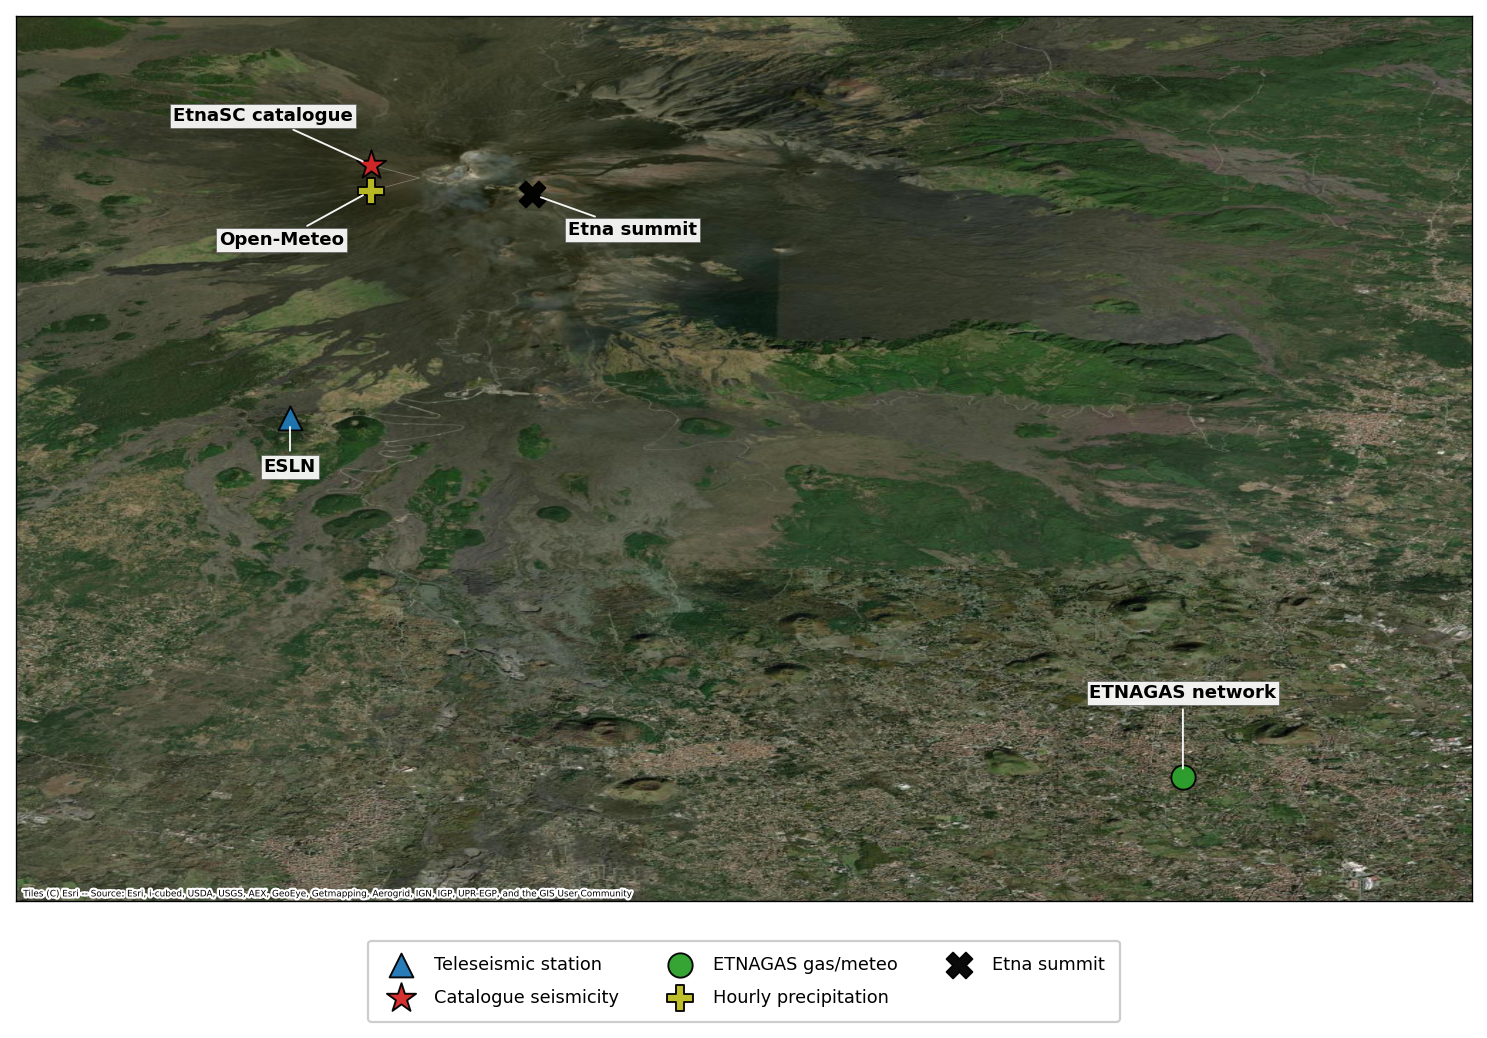

In [16]:
etna_meta = etna_observable_metadata()

fig, ax, etna_variable_table = plot_etna_all_variables_map(
    metadata=etna_meta,
    satellite=True, # for satellite imagery
    save_dir="figures",
    filename="etna_map",
)

etna_variable_table